In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display
import missingno as msno

## **1- Exploration initiale : Aperçu + Structure (premières lignes et doublons)**

In [2]:
#Import des donnees et premieres lignes
data = pd.read_csv('Fraud Detection Dataset.csv')
print('Import des données réussi !\n')

print('Aperçu des premières lignes\n')
display(data.head(5))

Import des données réussi !

Aperçu des premières lignes



,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Fraudulent
0,T1,4174,1292.76,ATM Withdrawal,16.0,Tablet,San Francisco,0,119,13,Debit Card,0
1,T2,4507,1554.58,ATM Withdrawal,13.0,Mobile,New York,4,79,3,Credit Card,0
2,T3,1860,2395.02,ATM Withdrawal,NaN,Mobile,NaN,3,115,9,NaN,0
3,T4,2294,100.10,Bill Payment,15.0,Desktop,Chicago,4,3,4,UPI,0
4,T5,2130,1490.50,POS Payment,19.0,Mobile,San Francisco,2,57,7,Credit Card,0


In [3]:
print('Infos du dataset\n')
data.info(verbose=True)

Infos du dataset

<class 'pandas.DataFrame'>
RangeIndex: 51000 entries, 0 to 50999
Data columns (total 12 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Transaction_ID                    51000 non-null  str    
 1   User_ID                           51000 non-null  int64  
 2   Transaction_Amount                48480 non-null  float64
 3   Transaction_Type                  51000 non-null  str    
 4   Time_of_Transaction               48448 non-null  float64
 5   Device_Used                       48527 non-null  str    
 6   Location                          48453 non-null  str    
 7   Previous_Fraudulent_Transactions  51000 non-null  int64  
 8   Account_Age                       51000 non-null  int64  
 9   Number_of_Transactions_Last_24H   51000 non-null  int64  
 10  Payment_Method                    48531 non-null  str    
 11  Fraudulent                        51000 non-null  int64  
dt

\
Nous pouvons à partir de cette sortie, faire les remarques suivantes :
* **Shape du dataset :** 51000 lignes x 12 colonnes
* **Types de données :** `float`(2), `int`(5), `str`(5) $\rightarrow$ pas de type `object`
* Présence de valeurs manquantes sur 5 colonnes de données

In [4]:
print('-'*70)
print(f'Nombre de doublons parfaits: {data.duplicated(subset=data.columns).sum()}')
print('-'*70)
data.drop_duplicates(subset=data.columns, inplace=True)
print(f'Shape après suppression des doublons parfaits : {data.shape}')
print('-'*70)

----------------------------------------------------------------------
Nombre de doublons parfaits: 881
----------------------------------------------------------------------
Shape après suppression des doublons parfaits : (50119, 12)
----------------------------------------------------------------------


## **2- Valeurs manquantes**

Valeurs manquantes par colonne



,count,pct
Transaction_ID,0,0.000000
User_ID,0,0.000000
Transaction_Amount,2476,0.049402
Transaction_Type,0,0.000000
Time_of_Transaction,2505,0.049981
Device_Used,2437,0.048624
Location,2500,0.049881
Previous_Fraudulent_Transactions,0,0.000000
Account_Age,0,0.000000
Number_of_Transactions_Last_24H,0,0.000000


c:\Users\c1718\Documents\TPs\tp_venv\Lib\site-packages\missingno\missingno.py:61: UserWarning: Plotting a sparkline on an existing axis is not currently supported. To remove this warning, set sparkline=False.
  warnings.warn(


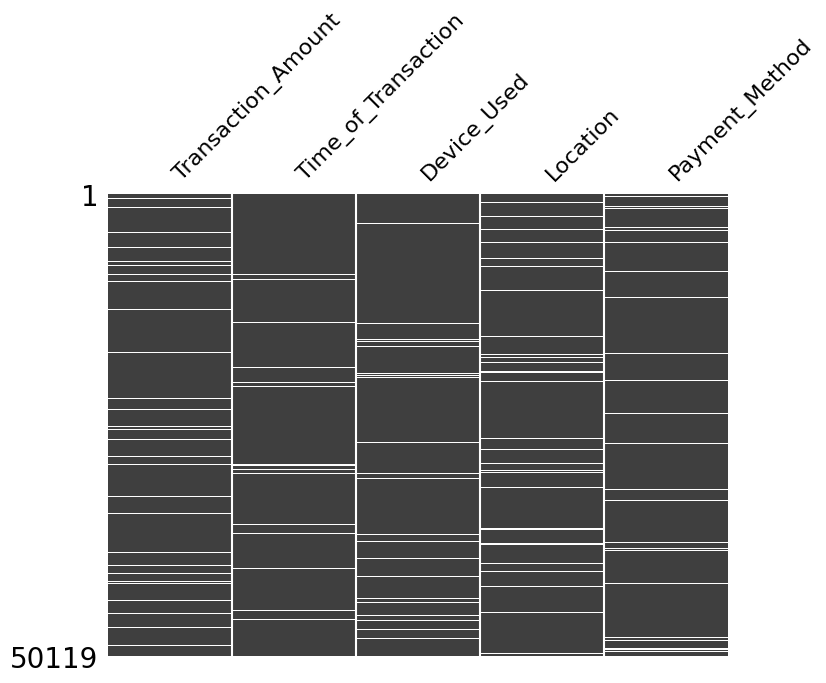

In [5]:
print('Valeurs manquantes par colonne\n')
display(pd.DataFrame({
    'count': data.isna().sum(),
    'pct': data.isna().sum() / len(data)
}))


fig, ax = plt.subplots(1, 1,figsize=(8, 6))
msno.matrix(df=data.loc[:, ['Transaction_Amount', 'Time_of_Transaction', 'Device_Used', 'Location', 'Payment_Method']],
            ax= ax)
plt.show()

## **3- Analyse des variables numériques**

In [6]:
print('-'*50)
print('Statistiques descriptives')
print('-'*50)

print('\n')

display(data.drop(columns=['Fraudulent', 'User_ID']).describe())

--------------------------------------------------
Statistiques descriptives
--------------------------------------------------




,Transaction_Amount,Time_of_Transaction,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H
count,47643.000000,47614.000000,50119.000000,50119.000000,50119.000000
mean,2999.104599,11.488575,1.996448,60.029071,7.495640
std,5061.206189,6.921244,1.415492,34.392569,4.019806
min,5.030000,0.000000,0.000000,1.000000,1.000000
25%,1269.830000,5.000000,1.000000,30.000000,4.000000
50%,2523.580000,12.000000,2.000000,60.000000,7.000000
75%,3785.090000,17.000000,3.000000,90.000000,11.000000
max,49997.800000,23.000000,4.000000,119.000000,14.000000


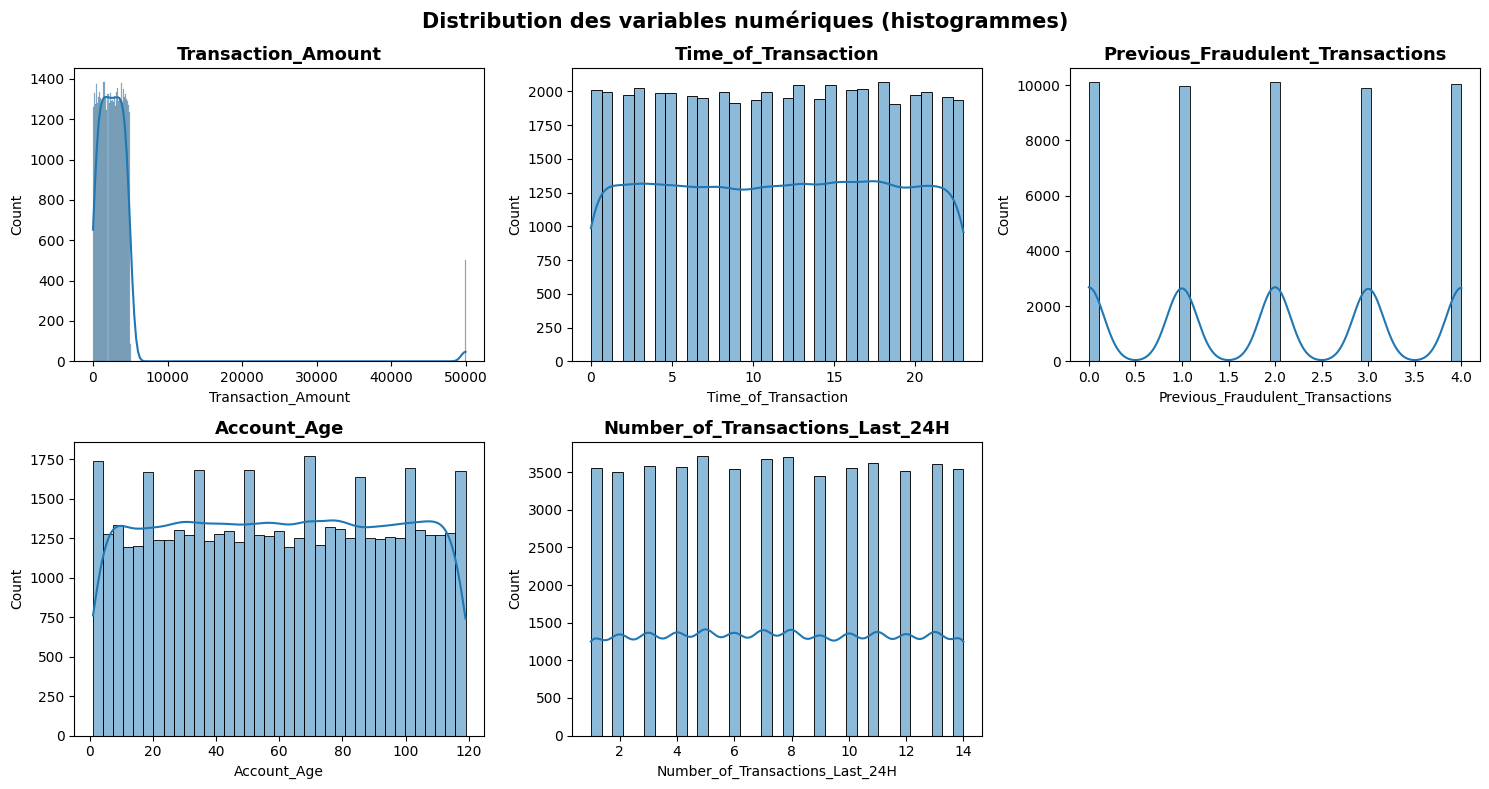

In [7]:
fig, ax = plt.subplots(2, 3, figsize=(15, 8))

fig.suptitle('Distribution des variables numériques (histogrammes)', fontweight='bold', fontsize=15)
ax_flat = ax.flatten()

cols= ['Transaction_Amount', 'Time_of_Transaction', 'Previous_Fraudulent_Transactions', 'Account_Age', 'Number_of_Transactions_Last_24H']

for idx, col in enumerate(cols):
    sns.histplot(data=data[col], ax= ax_flat[idx], kde=True)
    ax_flat[idx].set_title(col, fontweight='bold', fontsize=13)

ax_flat[-1].set_visible(False)

plt.tight_layout()
plt.show()


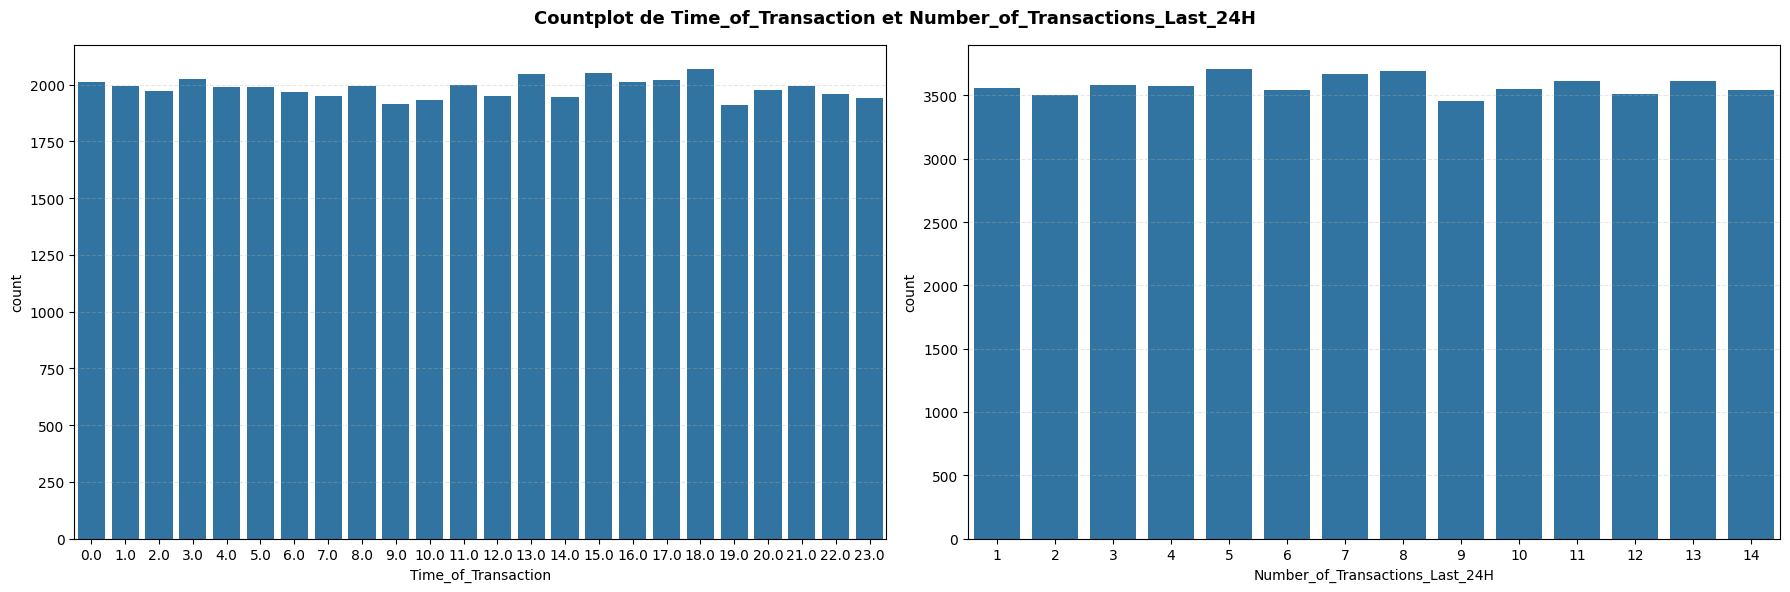

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(18, 6))

fig.suptitle('Countplot de Time_of_Transaction et Number_of_Transactions_Last_24H', fontweight='bold', fontsize=13)

for idx, col in enumerate(['Time_of_Transaction', 'Number_of_Transactions_Last_24H']):
    sns.countplot(data=data, x=col, ax=ax[idx])
    ax[idx].grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

## **4- Analyse des variables catégorielles**

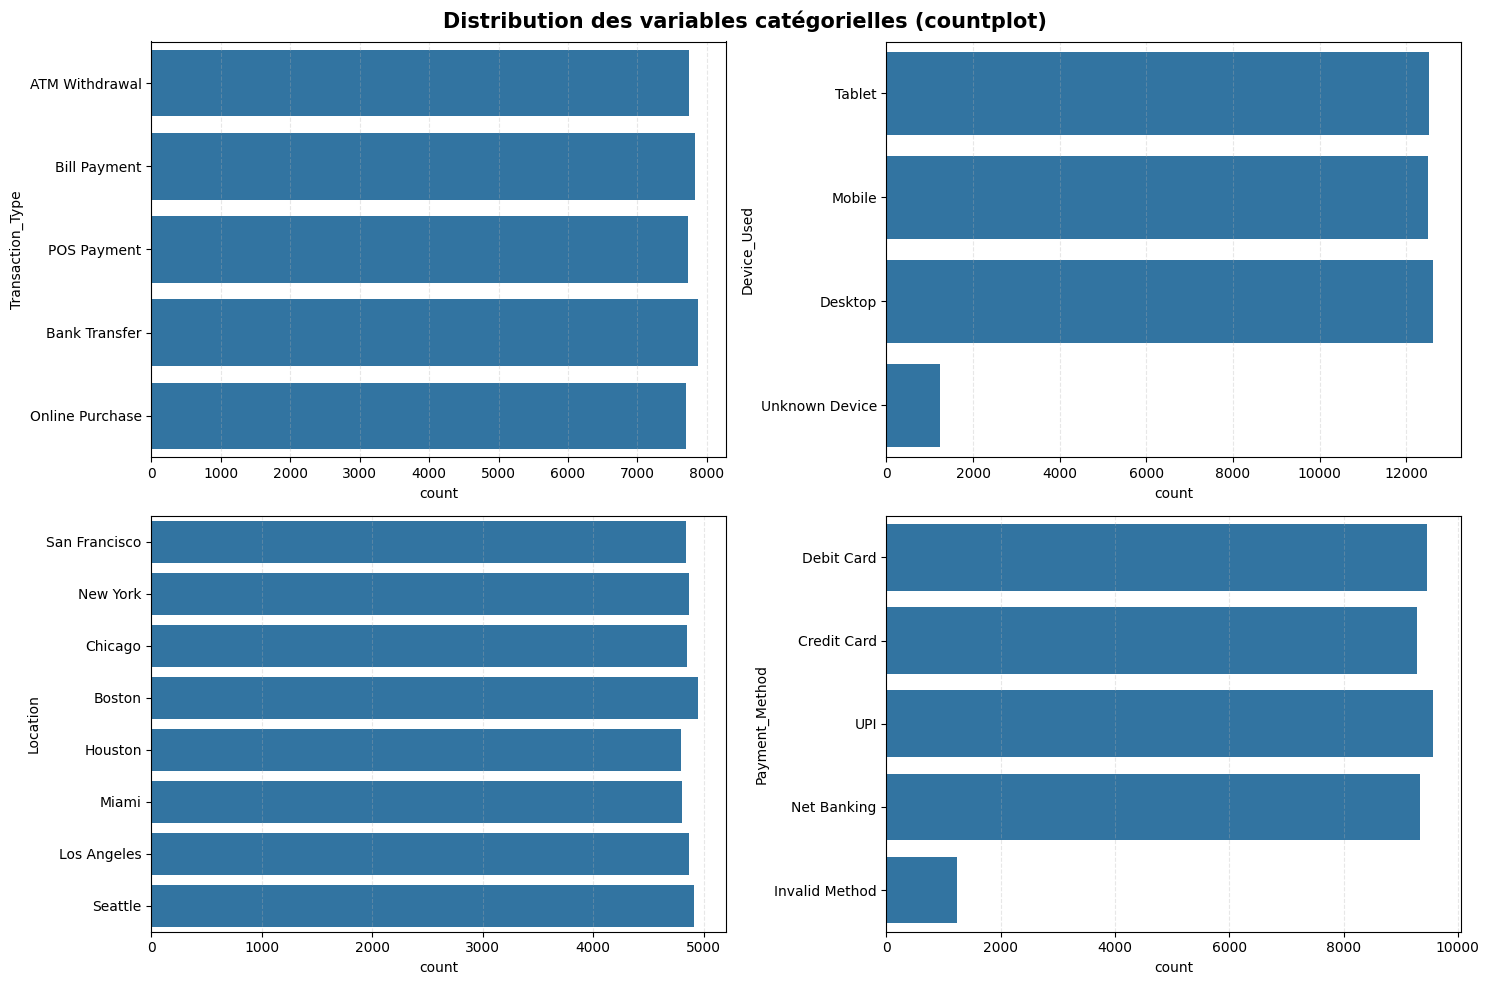

In [9]:
cols =['Transaction_Type', 'Device_Used', 'Location', 'Payment_Method']
fig, ax=plt.subplots(2, 2, figsize=(15, 10))

fig.suptitle('Distribution des variables catégorielles (countplot)', fontsize=15, fontweight='bold')
ax_flat = ax.flatten()

dt = data.copy()
dt.dropna(inplace=True)

for idx, col in enumerate(cols):
    sns.countplot(data=dt, y=col, ax=ax_flat[idx])
    ax_flat[idx].grid(axis='x', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

## **5- Traitement des variables manquantes**


* `Transaction_Amount`$\rightarrow$ On remplace les NaN par la médiane
* `Device_Used` $\rightarrow$ On remplace par la modalité `Unknown Device`
* `Payment_Method` $\rightarrow$ On remplace par la modalité `Invalid Method`
* `Time_of_Transaction` et `Location` : On supprime

In [10]:
data.fillna({'Transaction_Amount' : 2523.6}, inplace=True)

data.fillna({'Device_Used': 'Unknown Device'}, inplace=True)

data.fillna({'Payment_Method': 'Invalid Method'}, inplace=True)

print('Valeurs manquantes par colonne\n')
display(data.isna().sum())

Valeurs manquantes par colonne



Transaction_ID                         0
User_ID                                0
Transaction_Amount                     0
Transaction_Type                       0
Time_of_Transaction                 2505
Device_Used                            0
Location                            2500
Previous_Fraudulent_Transactions       0
Account_Age                            0
Number_of_Transactions_Last_24H        0
Payment_Method                         0
Fraudulent                             0
dtype: int64

In [11]:
print('-'*70)
print('Shape avant suppression des valeurs manquantes : {}'.format(data.shape))
print('-'*70)

data.dropna(inplace=True)

print('Shape après suppression des valeurs manquantes : {}'.format(data.shape))
print('-'*70)

----------------------------------------------------------------------
Shape avant suppression des valeurs manquantes : (50119, 12)
----------------------------------------------------------------------
Shape après suppression des valeurs manquantes : (45242, 12)
----------------------------------------------------------------------


## **6- Analyse de la variable cible**

Text(0.5, 1.0, 'Pieplot de la cible')

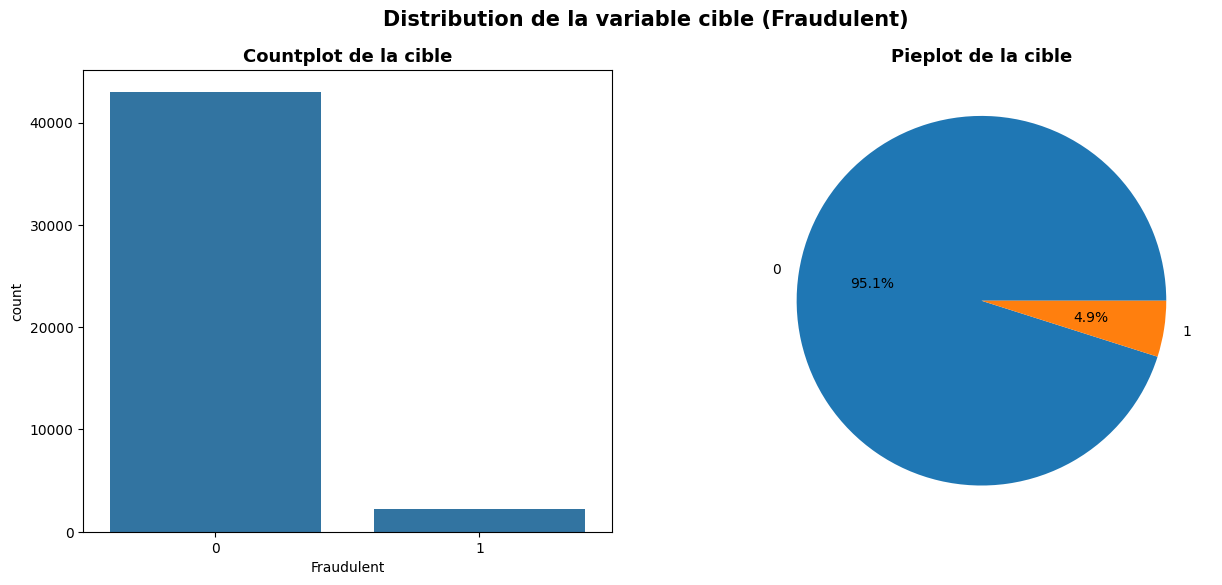

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

fig.suptitle('Distribution de la variable cible (Fraudulent)', fontweight='bold', fontsize=15)

sns.countplot(data=data, x='Fraudulent', ax=ax[0])
ax[0].set_title('Countplot de la cible', fontsize=13, fontweight='bold')

data['Fraudulent'].value_counts().plot.pie(autopct='%1.1f%%', ax=ax[1])
ax[1].set_title('Pieplot de la cible', fontsize=13, fontweight='bold')

\
On remarque un fort déséquilibre de la variable cible (seulement 4.9% de données frauduleuses). 

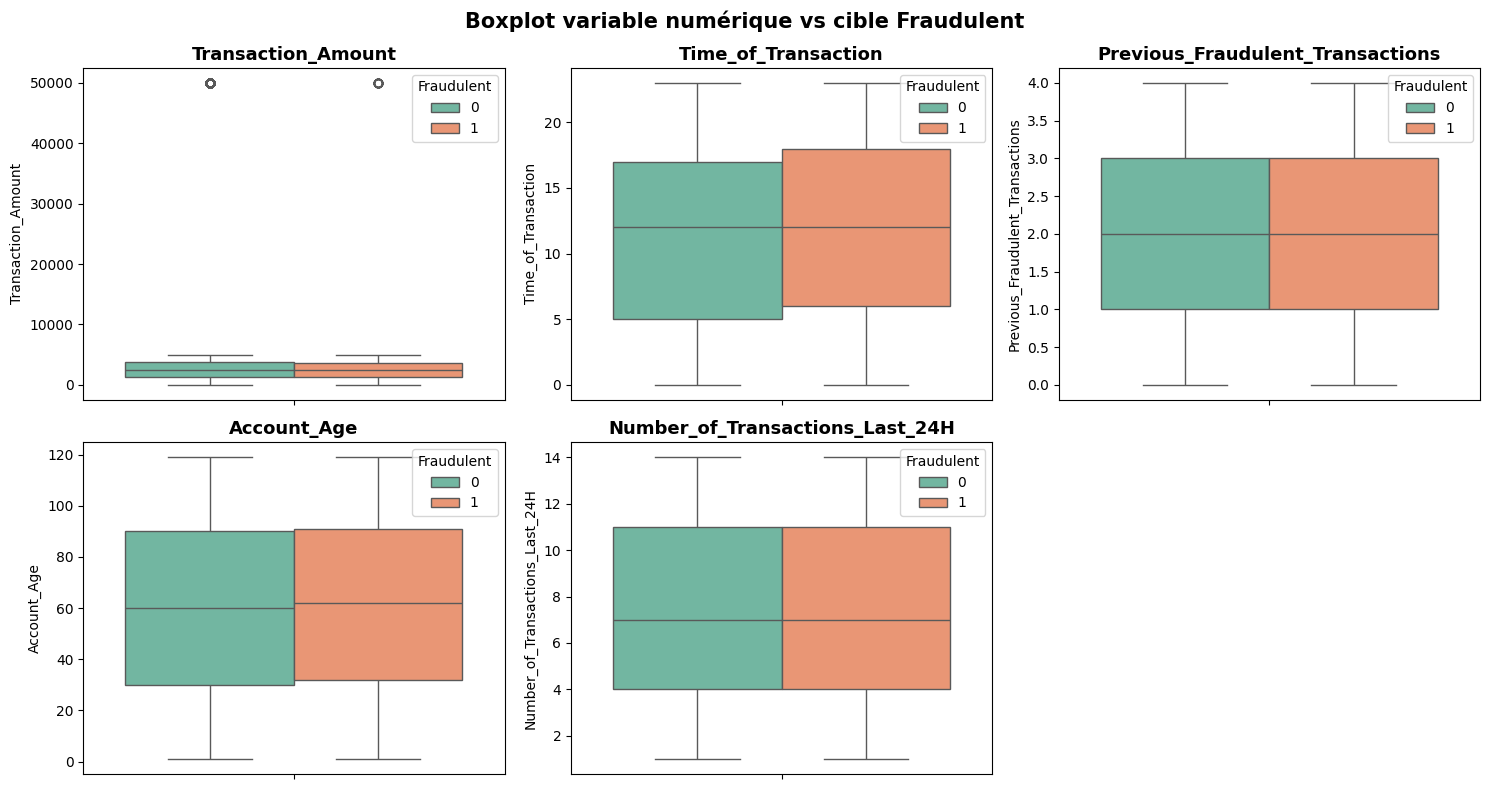

In [13]:
fig, ax = plt.subplots(2, 3, figsize=(15, 8))

fig.suptitle('Boxplot variable numérique vs cible Fraudulent', fontweight='bold', fontsize=15)
ax_flat = ax.flatten()

cols= ['Transaction_Amount', 'Time_of_Transaction', 'Previous_Fraudulent_Transactions', 'Account_Age', 'Number_of_Transactions_Last_24H']

for idx, col in enumerate(cols):
    sns.boxplot(data=data, hue='Fraudulent', y=col, ax= ax_flat[idx], palette='Set2', legend=True)
    ax_flat[idx].set_title(col, fontweight='bold', fontsize=13)

ax_flat[-1].set_visible(False)

plt.tight_layout()
plt.show()

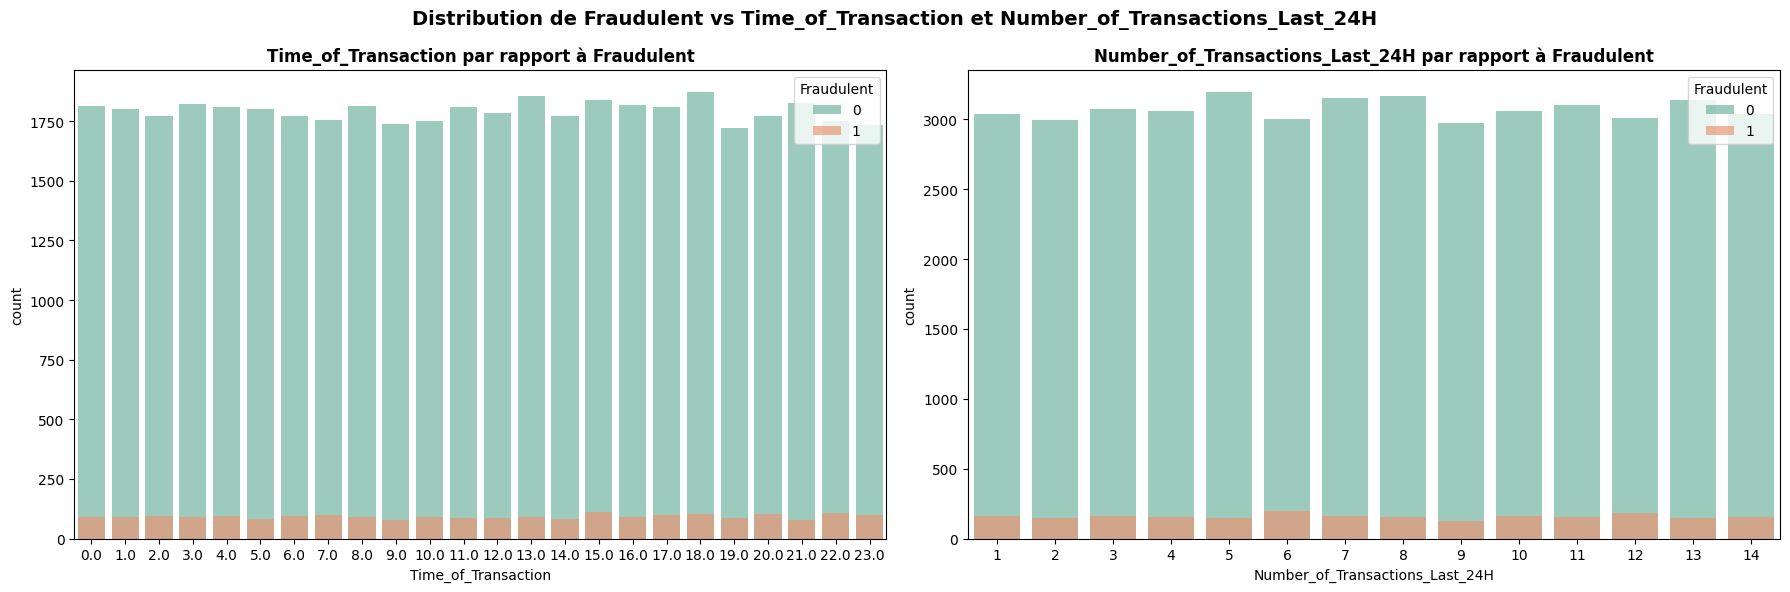

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(18, 6))

fig.suptitle('Distribution de Fraudulent vs Time_of_Transaction et Number_of_Transactions_Last_24H', 
             fontweight='bold', fontsize=14)

# Countplot pour Time_of_Transaction
sns.countplot(data=data, x='Time_of_Transaction', hue='Fraudulent', ax=ax[0], palette='Set2', dodge=False, alpha=0.7)
ax[0].set_title('Time_of_Transaction par rapport à Fraudulent', fontweight='bold', fontsize=12)

# Countplot pour Number_of_Transactions_Last_24H
sns.countplot(data=data, x='Number_of_Transactions_Last_24H', hue='Fraudulent', ax=ax[1], palette='Set2', dodge=False, alpha=0.7)
ax[1].set_title('Number_of_Transactions_Last_24H par rapport à Fraudulent', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

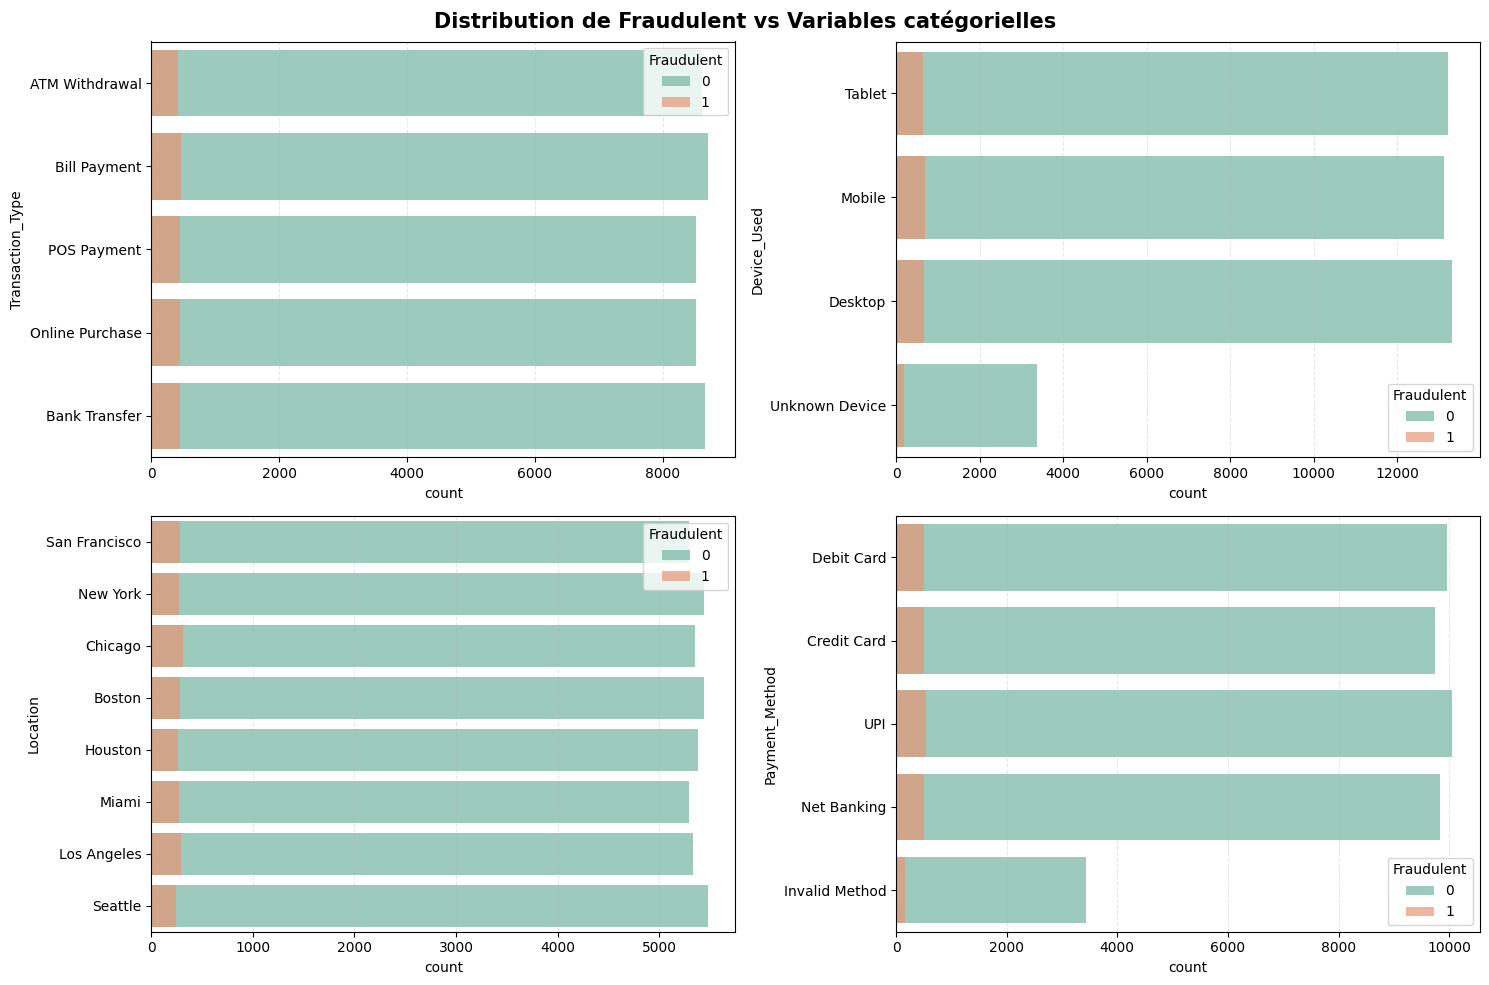

In [15]:
cols =['Transaction_Type', 'Device_Used', 'Location', 'Payment_Method']
fig, ax=plt.subplots(2, 2, figsize=(15, 10))

fig.suptitle('Distribution de Fraudulent vs Variables catégorielles', fontsize=15, fontweight='bold')
ax_flat = ax.flatten()

dt = data.copy()
dt.dropna(inplace=True)

for idx, col in enumerate(cols):
    sns.countplot(data=dt, y=col, hue='Fraudulent', ax=ax_flat[idx], dodge=False, alpha=0.7, palette='Set2')
    ax_flat[idx].grid(axis='x', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

## **7- Feature engineering et Data Preparation**

In [16]:
data['Period_of_Transaction'] = pd.cut(data['Time_of_Transaction'], 
                                       bins=[-1.0, 3.0, 7.0, 11.0, 15.0, 19.0, 24.0],
                                       labels=['P1', 'P2', 'P3', 'P4', 'P5', 'P6'])

data.head()

,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Fraudulent,Period_of_Transaction
0,T1,4174,1292.76,ATM Withdrawal,16.0,Tablet,San Francisco,0,119,13,Debit Card,0,P5
1,T2,4507,1554.58,ATM Withdrawal,13.0,Mobile,New York,4,79,3,Credit Card,0,P4
3,T4,2294,100.10,Bill Payment,15.0,Desktop,Chicago,4,3,4,UPI,0,P4
4,T5,2130,1490.50,POS Payment,19.0,Mobile,San Francisco,2,57,7,Credit Card,0,P5
5,T6,2095,2372.04,ATM Withdrawal,15.0,Desktop,Boston,3,96,14,Credit Card,0,P4


In [17]:
data.drop(columns=['Transaction_ID', 'User_ID', 'Time_of_Transaction'], inplace=True)

data.head()

,Transaction_Amount,Transaction_Type,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Fraudulent,Period_of_Transaction
0,1292.76,ATM Withdrawal,Tablet,San Francisco,0,119,13,Debit Card,0,P5
1,1554.58,ATM Withdrawal,Mobile,New York,4,79,3,Credit Card,0,P4
3,100.10,Bill Payment,Desktop,Chicago,4,3,4,UPI,0,P4
4,1490.50,POS Payment,Mobile,San Francisco,2,57,7,Credit Card,0,P5
5,2372.04,ATM Withdrawal,Desktop,Boston,3,96,14,Credit Card,0,P4


## **8. Machine Learning - Decision Tree Classifier**

## Objectif
Construire et optimiser un modèle de **Decision Tree Classifier** pour détecter les transactions frauduleuses, en gérant le déséquilibre important des classes.

In [20]:
# ====================================================================================
# IMPORTS ADDITIONNELS POUR LE ML
# ====================================================================================

from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix, 
                             accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, roc_curve, auc,
                             ConfusionMatrixDisplay, precision_recall_curve)

print('✓ Imports ML réussis')

✓ Imports ML réussis


### Étape 1 : Encodage des Variables Catégorielles

In [21]:
# Encodage des variables catégorielles
categorical_cols = data.select_dtypes(include=['str', 'category']).columns.tolist()
print(f'Colonnes catégorielles : {categorical_cols}\n')

label_encoders = {}
data_encoded = data.copy()

for col in categorical_cols:
    le = LabelEncoder()
    data_encoded[col] = le.fit_transform(data[col].astype(str))
    label_encoders[col] = le
    print(f'✓ {col} encodée')

print(f'\n✓ Encodage terminé ! Shape : {data_encoded.shape}')

Colonnes catégorielles : ['Transaction_Type', 'Device_Used', 'Location', 'Payment_Method', 'Period_of_Transaction']

✓ Transaction_Type encodée
✓ Device_Used encodée
✓ Location encodée
✓ Payment_Method encodée
✓ Period_of_Transaction encodée

✓ Encodage terminé ! Shape : (45242, 10)


In [23]:
data_encoded.head()

,Transaction_Amount,Transaction_Type,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Fraudulent,Period_of_Transaction
0,1292.76,0,2,6,0,119,13,1,0,4
1,1554.58,0,1,5,4,79,3,0,0,3
3,100.10,2,0,1,4,3,4,4,0,3
4,1490.50,4,1,6,2,57,7,0,0,4
5,2372.04,0,0,0,3,96,14,0,0,3


### Étape 2 : Split des Données avec Stratification

In [24]:
# Préparation des features et target
X = data_encoded.drop('Fraudulent', axis=1)
y = data_encoded['Fraudulent']

print('='*70)
print('SPLIT DES DONNÉES AVEC STRATIFICATION (80% train/val, 20% test)')
print('='*70 + '\n')

# Split test/train+val avec stratification
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Split train/val avec stratification
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.20, random_state=42, stratify=y_temp
)

print(f'✓ X_train (64%) : {X_train.shape[0]} lignes')
print(f'✓ X_val (16%) : {X_val.shape[0]} lignes')
print(f'✓ X_test (20%) : {X_test.shape[0]} lignes\n')

# Vérification de la stratification
print('Vérification de la stratification :')
print(f'  Train - Frauduleuses : {(y_train == 1).sum() / len(y_train) * 100:.2f}%')
print(f'  Validation - Frauduleuses : {(y_val == 1).sum() / len(y_val) * 100:.2f}%')
print(f'  Test - Frauduleuses : {(y_test == 1).sum() / len(y_test) * 100:.2f}%')
print('✓ Stratification réussie !')

SPLIT DES DONNÉES AVEC STRATIFICATION (80% train/val, 20% test)

✓ X_train (64%) : 28954 lignes
✓ X_val (16%) : 7239 lignes
✓ X_test (20%) : 9049 lignes

Vérification de la stratification :
  Train - Frauduleuses : 4.90%
  Validation - Frauduleuses : 4.90%
  Test - Frauduleuses : 4.90%
✓ Stratification réussie !


### Étape 3 : Modèle Baseline - Decision Tree

In [29]:
# Entraînement du modèle baseline
dt_baseline = DecisionTreeClassifier(random_state=42, class_weight='balanced')
dt_baseline.fit(X_train, y_train)

print(f'✓ Modèle baseline entraîné')
print(f'  - Profondeur : {dt_baseline.get_depth()}')
print(f'  - Feuilles : {dt_baseline.get_n_leaves()}\n')

# Prédictions
y_train_proba_bl = dt_baseline.predict_proba(X_train)[:, 1]
y_val_proba_bl = dt_baseline.predict_proba(X_val)[:, 1]
y_test_proba_bl = dt_baseline.predict_proba(X_test)[:, 1]

# Fonction d'évaluation
def evaluate_model(model, X_train, X_val, X_test, y_train, y_val, y_test,
                   y_train_proba, y_val_proba, y_test_proba):
    metrics = {}
    for set_name, X_data, y_true, y_proba in [
        ('Train', X_train, y_train, y_train_proba),
        ('Validation', X_val, y_val, y_val_proba),
        ('Test', X_test, y_test, y_test_proba)
    ]:
        y_pred = model.predict(X_data)
        metrics[set_name] = {
            'accuracy': accuracy_score(y_true, y_pred),
            'precision': precision_score(y_true, y_pred, zero_division=0),
            'recall': recall_score(y_true, y_pred, zero_division=0),
            'f1': f1_score(y_true, y_pred, zero_division=0),
            'roc_auc': roc_auc_score(y_true, y_proba)
        }
    return metrics

metrics_bl = evaluate_model(dt_baseline, X_train, X_val, X_test, y_train, y_val, y_test,
                             y_train_proba_bl, y_val_proba_bl, y_test_proba_bl)

print('PERFORMANCES - BASELINE')
print(pd.DataFrame(metrics_bl).T.to_string())

✓ Modèle baseline entraîné
  - Profondeur : 44
  - Feuilles : 3254

PERFORMANCES - BASELINE
            accuracy  precision    recall        f1   roc_auc
Train       1.000000   1.000000  1.000000  1.000000  1.000000
Validation  0.906893   0.070081  0.073239  0.071625  0.511562
Test        0.904299   0.045161  0.047404  0.046256  0.497906


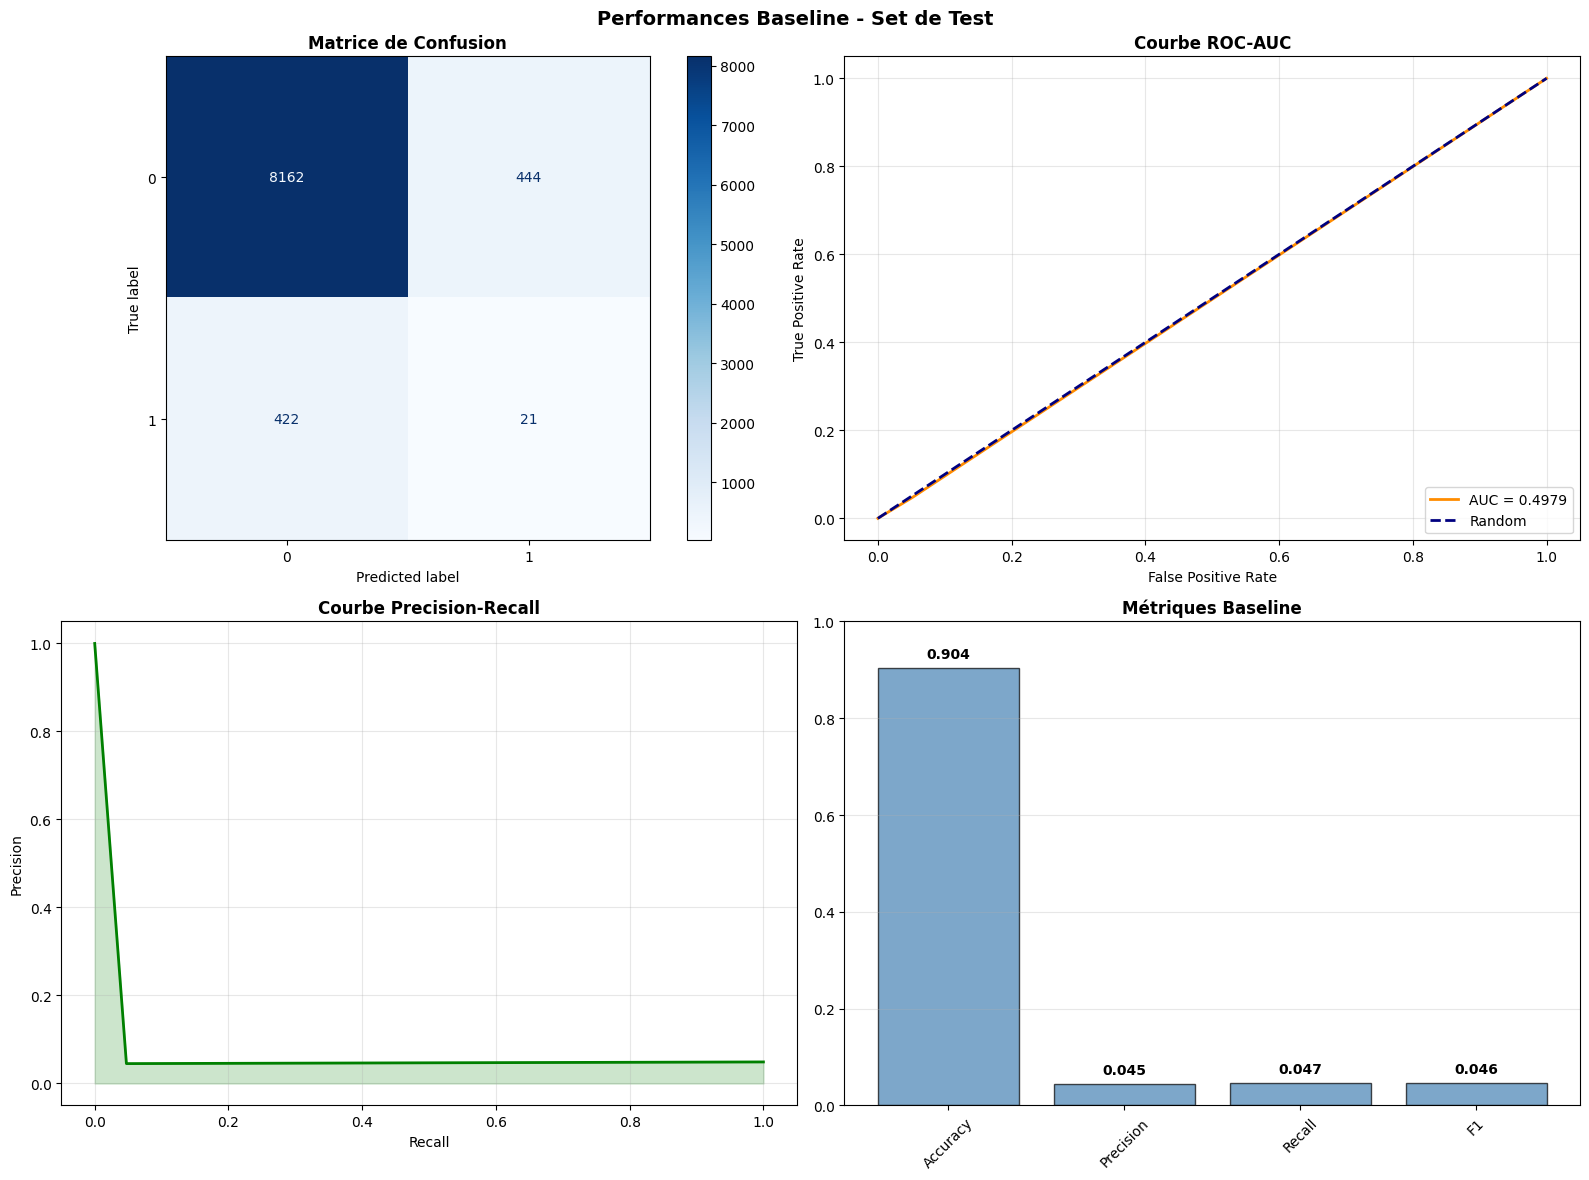

In [30]:
# Visualisations Baseline
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Performances Baseline - Set de Test', fontsize=14, fontweight='bold')

# 1. Matrice de confusion
y_test_pred_bl = dt_baseline.predict(X_test)
cm_bl = confusion_matrix(y_test, y_test_pred_bl)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_bl)
disp.plot(ax=axes[0, 0], cmap='Blues', values_format='d')
axes[0, 0].set_title('Matrice de Confusion', fontweight='bold')

# 2. Courbe ROC-AUC
fpr_bl, tpr_bl, _ = roc_curve(y_test, y_test_proba_bl)
roc_auc_bl = roc_auc_score(y_test, y_test_proba_bl)
axes[0, 1].plot(fpr_bl, tpr_bl, color='darkorange', lw=2, label=f'AUC = {roc_auc_bl:.4f}')
axes[0, 1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
axes[0, 1].set_xlabel('False Positive Rate')
axes[0, 1].set_ylabel('True Positive Rate')
axes[0, 1].set_title('Courbe ROC-AUC', fontweight='bold')
axes[0, 1].legend(loc='lower right')
axes[0, 1].grid(alpha=0.3)

# 3. Precision-Recall
prec_bl, rec_bl, _ = precision_recall_curve(y_test, y_test_proba_bl)
axes[1, 0].plot(rec_bl, prec_bl, color='green', lw=2)
axes[1, 0].fill_between(rec_bl, prec_bl, alpha=0.2, color='green')
axes[1, 0].set_xlabel('Recall')
axes[1, 0].set_ylabel('Precision')
axes[1, 0].set_title('Courbe Precision-Recall', fontweight='bold')
axes[1, 0].grid(alpha=0.3)

# 4. Métriques
metrics_bl_test = [metrics_bl['Test'][m] for m in ['accuracy', 'precision', 'recall', 'f1']]
axes[1, 1].bar(range(4), metrics_bl_test, color='steelblue', alpha=0.7, edgecolor='black')
axes[1, 1].set_xticks(range(4))
axes[1, 1].set_xticklabels(['Accuracy', 'Precision', 'Recall', 'F1'], rotation=45)
axes[1, 1].set_ylim([0, 1])
axes[1, 1].set_title('Métriques Baseline', fontweight='bold')
axes[1, 1].grid(axis='y', alpha=0.3)

for i, v in enumerate(metrics_bl_test):
    axes[1, 1].text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

### Étape 4 : Optimisation avec Random Search

In [31]:
print('Lancement de Random Search (100 itérations, cela peut prendre ~10-15 secondes)...\n')

# Espace des hyperparamètres
param_dist = {
    'max_depth': [5, 10, 15, 20, 25, 30, None],
    'min_samples_split': [2, 5, 10, 20, 30],
    'min_samples_leaf': [1, 2, 4, 8, 10],
    'max_features': ['sqrt', 'log2', None],
    'criterion': ['gini', 'entropy'],
    'class_weight': ['balanced', None]
}

# Random Search
random_search = RandomizedSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_dist,
    n_iter=100,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    random_state=42,
    verbose=0
)

random_search.fit(X_train, y_train)

print('✓ Random Search terminée\n')
print('Meilleurs hyperparamètres trouvés :')
for param, value in random_search.best_params_.items():
    print(f'  • {param} = {value}')
print(f'\nMeilleur score CV (ROC-AUC) : {random_search.best_score_:.4f}')

Lancement de Random Search (100 itérations, cela peut prendre ~10-15 secondes)...

✓ Random Search terminée

Meilleurs hyperparamètres trouvés :
  • min_samples_split = 30
  • min_samples_leaf = 8
  • max_features = sqrt
  • max_depth = 15
  • criterion = entropy
  • class_weight = balanced

Meilleur score CV (ROC-AUC) : 0.5149


### Étape 5 : Modèle Optimisé

In [32]:
# Entraînement du modèle optimisé
dt_optimized = DecisionTreeClassifier(**random_search.best_params_, random_state=42)
dt_optimized.fit(X_train, y_train)

print(f'✓ Modèle optimisé entraîné')
print(f'  - Profondeur : {dt_optimized.get_depth()}')
print(f'  - Feuilles : {dt_optimized.get_n_leaves()}\n')

# Prédictions
y_train_proba_opt = dt_optimized.predict_proba(X_train)[:, 1]
y_val_proba_opt = dt_optimized.predict_proba(X_val)[:, 1]
y_test_proba_opt = dt_optimized.predict_proba(X_test)[:, 1]

# Évaluation
metrics_opt = evaluate_model(dt_optimized, X_train, X_val, X_test, y_train, y_val, y_test,
                              y_train_proba_opt, y_val_proba_opt, y_test_proba_opt)

print('PERFORMANCES - MODÈLE OPTIMISÉ')
print(pd.DataFrame(metrics_opt).T.to_string())

✓ Modèle optimisé entraîné
  - Profondeur : 15
  - Feuilles : 784

PERFORMANCES - MODÈLE OPTIMISÉ
            accuracy  precision    recall        f1   roc_auc
Train       0.690682   0.124539  0.880902  0.218226  0.860021
Validation  0.640144   0.044165  0.307042  0.077223  0.484454
Test        0.644381   0.047898  0.331828  0.083713  0.503720


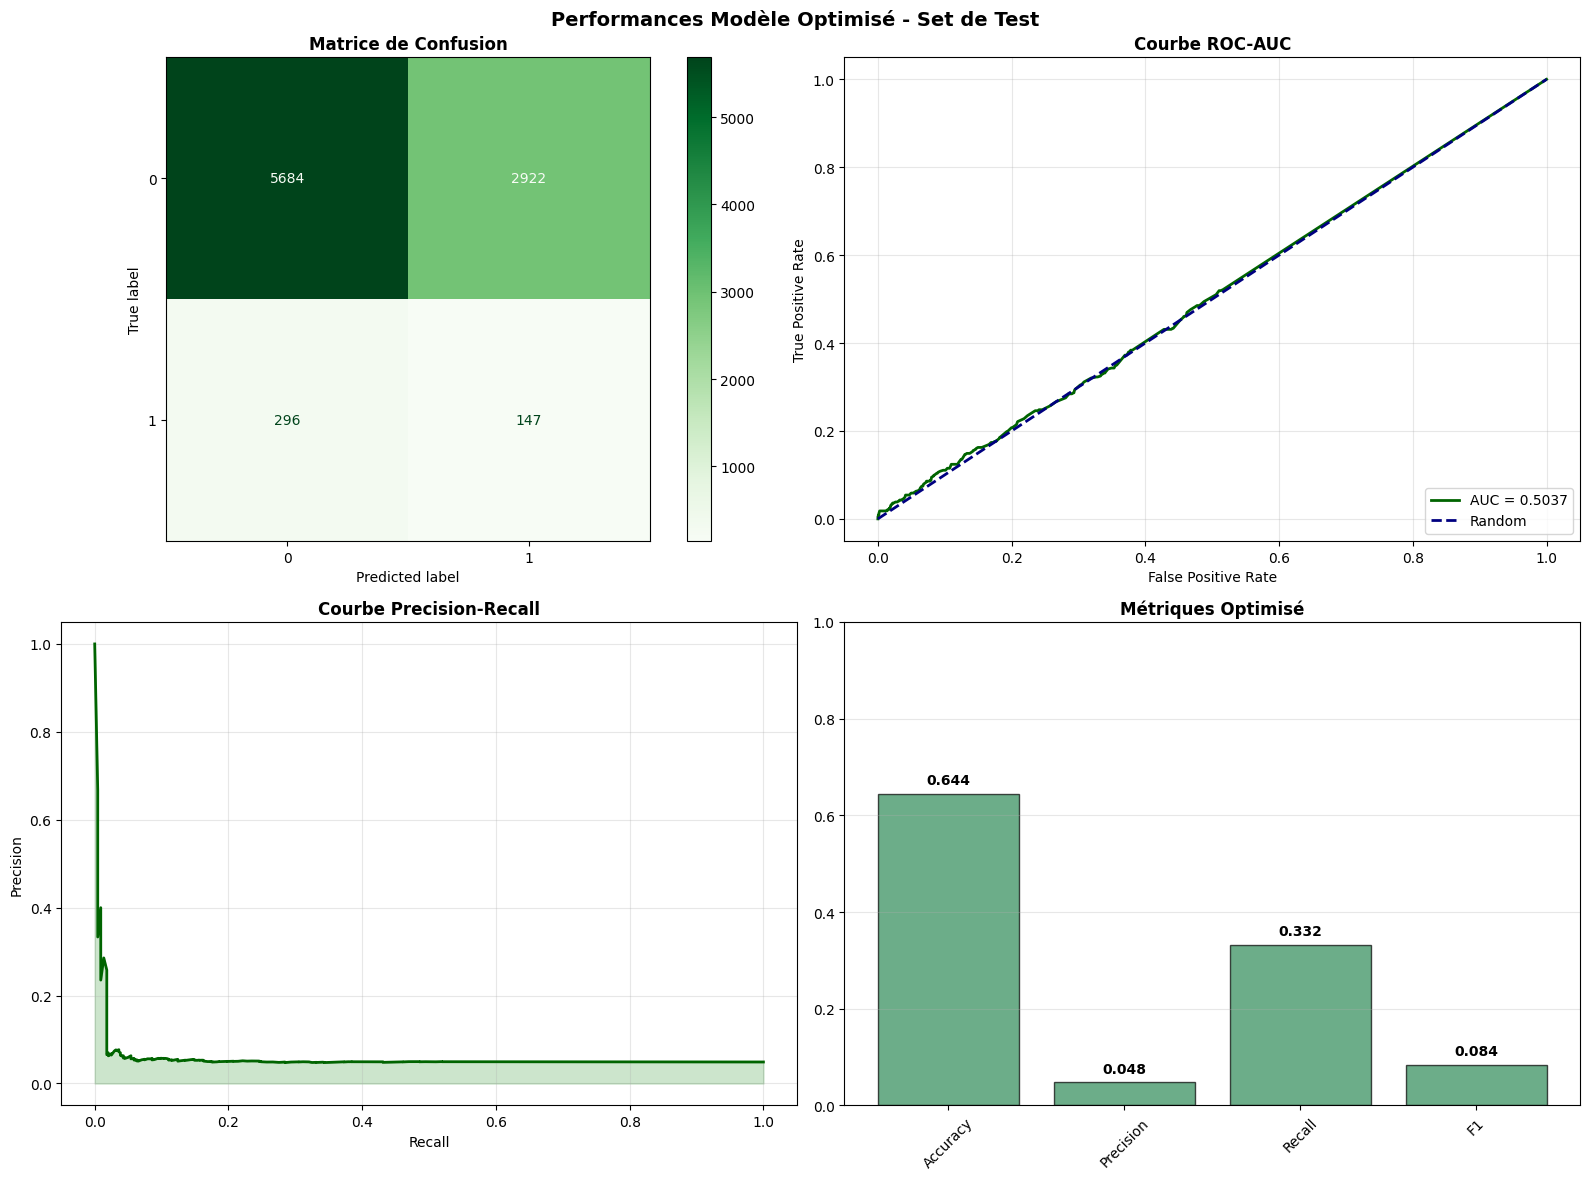

In [33]:
# Visualisations Optimisé
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Performances Modèle Optimisé - Set de Test', fontsize=14, fontweight='bold')

# 1. Matrice de confusion
y_test_pred_opt = dt_optimized.predict(X_test)
cm_opt = confusion_matrix(y_test, y_test_pred_opt)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_opt)
disp.plot(ax=axes[0, 0], cmap='Greens', values_format='d')
axes[0, 0].set_title('Matrice de Confusion', fontweight='bold')

# 2. Courbe ROC-AUC
fpr_opt, tpr_opt, _ = roc_curve(y_test, y_test_proba_opt)
roc_auc_opt = roc_auc_score(y_test, y_test_proba_opt)
axes[0, 1].plot(fpr_opt, tpr_opt, color='darkgreen', lw=2, label=f'AUC = {roc_auc_opt:.4f}')
axes[0, 1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
axes[0, 1].set_xlabel('False Positive Rate')
axes[0, 1].set_ylabel('True Positive Rate')
axes[0, 1].set_title('Courbe ROC-AUC', fontweight='bold')
axes[0, 1].legend(loc='lower right')
axes[0, 1].grid(alpha=0.3)

# 3. Precision-Recall
prec_opt, rec_opt, _ = precision_recall_curve(y_test, y_test_proba_opt)
axes[1, 0].plot(rec_opt, prec_opt, color='darkgreen', lw=2)
axes[1, 0].fill_between(rec_opt, prec_opt, alpha=0.2, color='green')
axes[1, 0].set_xlabel('Recall')
axes[1, 0].set_ylabel('Precision')
axes[1, 0].set_title('Courbe Precision-Recall', fontweight='bold')
axes[1, 0].grid(alpha=0.3)

# 4. Métriques
metrics_opt_test = [metrics_opt['Test'][m] for m in ['accuracy', 'precision', 'recall', 'f1']]
axes[1, 1].bar(range(4), metrics_opt_test, color='seagreen', alpha=0.7, edgecolor='black')
axes[1, 1].set_xticks(range(4))
axes[1, 1].set_xticklabels(['Accuracy', 'Precision', 'Recall', 'F1'], rotation=45)
axes[1, 1].set_ylim([0, 1])
axes[1, 1].set_title('Métriques Optimisé', fontweight='bold')
axes[1, 1].grid(axis='y', alpha=0.3)

for i, v in enumerate(metrics_opt_test):
    axes[1, 1].text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

### Étape 6 : Comparaison Baseline vs Optimisé


COMPARAISON : BASELINE vs OPTIMISÉ (Test Set)

 Métrique  Baseline  Optimisé  Amélioration  Amélioration %
 Accuracy  0.904299  0.644381     -0.259918          -28.74
Precision  0.045161  0.047898      0.002737            6.06
   Recall  0.047404  0.331828      0.284424          600.00
 F1-Score  0.046256  0.083713      0.037457           80.98
  ROC-AUC  0.497906  0.503720      0.005814            1.17


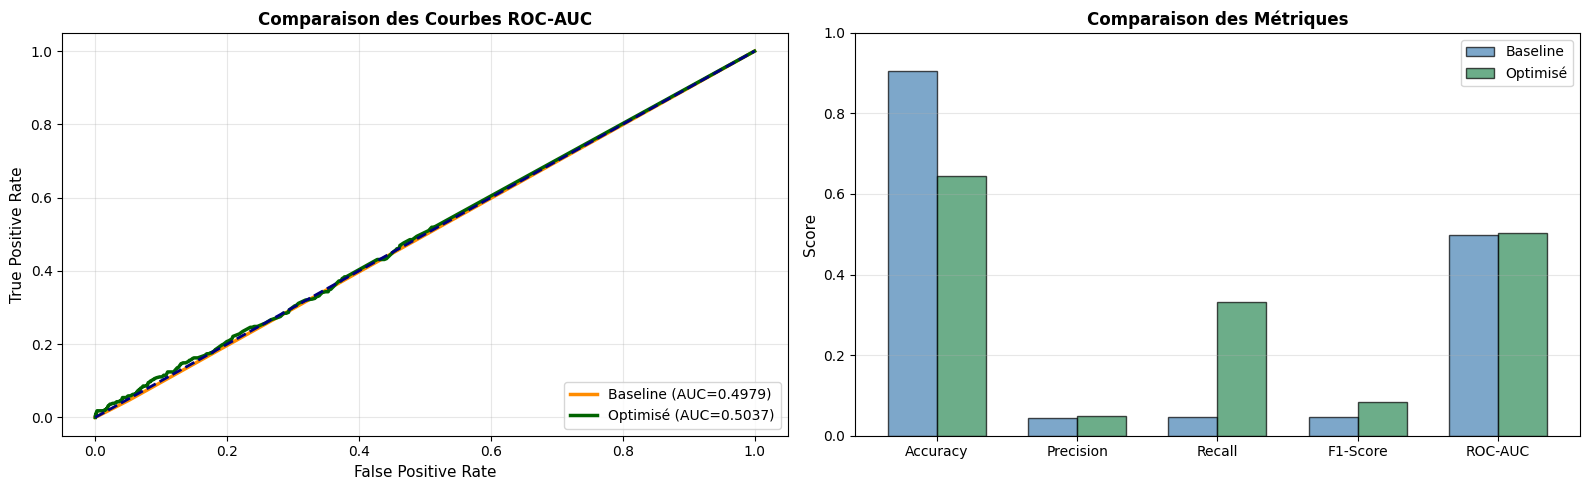

In [34]:
print('\n' + '='*70)
print('COMPARAISON : BASELINE vs OPTIMISÉ (Test Set)')
print('='*70 + '\n')

comparison_data = {
    'Métrique': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'],
    'Baseline': [metrics_bl['Test']['accuracy'], metrics_bl['Test']['precision'],
                 metrics_bl['Test']['recall'], metrics_bl['Test']['f1'], metrics_bl['Test']['roc_auc']],
    'Optimisé': [metrics_opt['Test']['accuracy'], metrics_opt['Test']['precision'],
                 metrics_opt['Test']['recall'], metrics_opt['Test']['f1'], metrics_opt['Test']['roc_auc']]
}

comparison_df = pd.DataFrame(comparison_data)
comparison_df['Amélioration'] = comparison_df['Optimisé'] - comparison_df['Baseline']
comparison_df['Amélioration %'] = (comparison_df['Amélioration'] / comparison_df['Baseline'] * 100).round(2)

print(comparison_df.to_string(index=False))

# Visualisation comparative
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Comparaison ROC curves
axes[0].plot(fpr_bl, tpr_bl, color='darkorange', lw=2.5, label=f'Baseline (AUC={roc_auc_bl:.4f})')
axes[0].plot(fpr_opt, tpr_opt, color='darkgreen', lw=2.5, label=f'Optimisé (AUC={roc_auc_opt:.4f})')
axes[0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[0].set_xlabel('False Positive Rate', fontsize=11)
axes[0].set_ylabel('True Positive Rate', fontsize=11)
axes[0].set_title('Comparaison des Courbes ROC-AUC', fontweight='bold', fontsize=12)
axes[0].legend(loc='lower right')
axes[0].grid(alpha=0.3)

# Barplot comparatif
x = np.arange(len(comparison_df))
width = 0.35
axes[1].bar(x - width/2, comparison_df['Baseline'], width, label='Baseline', 
            color='steelblue', alpha=0.7, edgecolor='black')
axes[1].bar(x + width/2, comparison_df['Optimisé'], width, label='Optimisé',
            color='seagreen', alpha=0.7, edgecolor='black')
axes[1].set_ylabel('Score', fontsize=11)
axes[1].set_title('Comparaison des Métriques', fontweight='bold', fontsize=12)
axes[1].set_xticks(x)
axes[1].set_xticklabels(comparison_df['Métrique'])
axes[1].set_ylim([0, 1])
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### Étape 7 : Importance des Features


Top 10 Features par Importance :
                         Feature  Importance
              Transaction_Amount    0.260614
                     Account_Age    0.222426
                        Location    0.088309
Previous_Fraudulent_Transactions    0.083159
 Number_of_Transactions_Last_24H    0.079486
                Transaction_Type    0.076470
           Period_of_Transaction    0.074892
                     Device_Used    0.073856
                  Payment_Method    0.040788


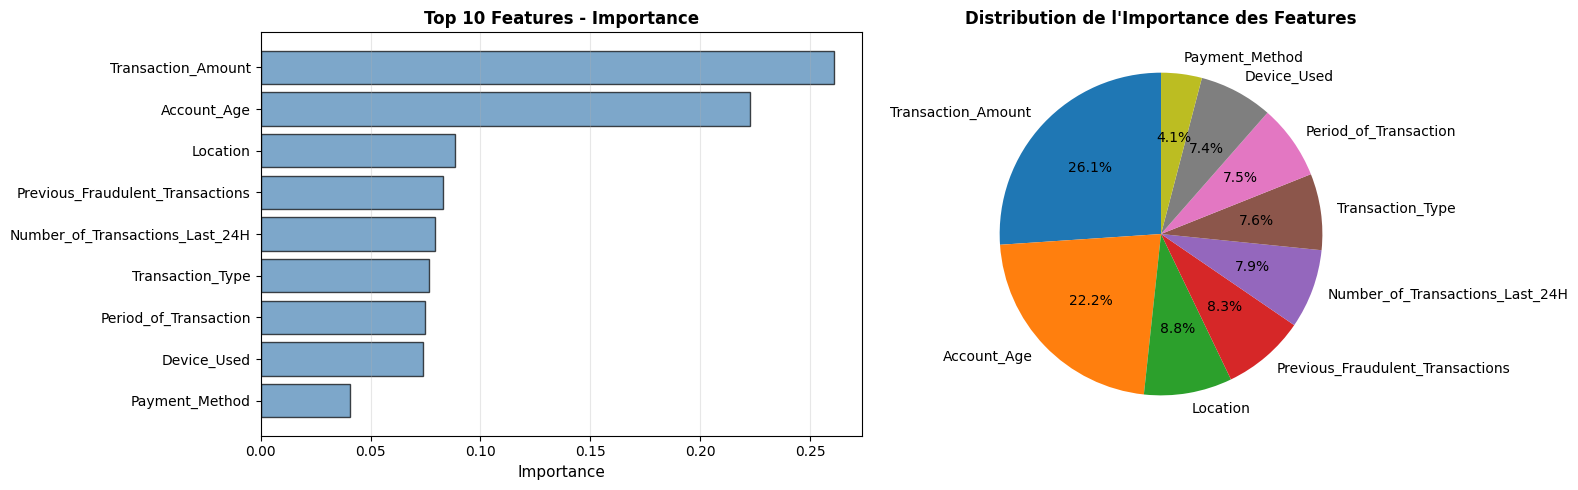

In [35]:
# Importance des features
feature_names = X.columns
feature_importance = dt_optimized.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importance
}).sort_values('Importance', ascending=False)

print('\nTop 10 Features par Importance :')
print(feature_importance_df.head(10).to_string(index=False))

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Barplot horizontal
top_10 = feature_importance_df.head(10)
axes[0].barh(range(len(top_10)), top_10['Importance'].values, color='steelblue', alpha=0.7, edgecolor='black')
axes[0].set_yticks(range(len(top_10)))
axes[0].set_yticklabels(top_10['Feature'].values)
axes[0].set_xlabel('Importance', fontsize=11)
axes[0].set_title('Top 10 Features - Importance', fontweight='bold')
axes[0].invert_yaxis()
axes[0].grid(axis='x', alpha=0.3)

# Pie chart
axes[1].pie(feature_importance_df['Importance'].values, labels=feature_importance_df['Feature'].values,
            autopct='%1.1f%%', startangle=90)
axes[1].set_title('Distribution de l\'Importance des Features', fontweight='bold')

plt.tight_layout()
plt.show()

### Étape 8 : Classification Report Détaillé

In [36]:
print('\n' + '='*70)
print('CLASSIFICATION REPORT - BASELINE (Test Set)')
print('='*70 + '\n')
print(classification_report(y_test, y_test_pred_bl, 
                           target_names=['Non-Frauduleuse', 'Frauduleuse']))

print('\n' + '='*70)
print('CLASSIFICATION REPORT - OPTIMISÉ (Test Set)')
print('='*70 + '\n')
print(classification_report(y_test, y_test_pred_opt,
                           target_names=['Non-Frauduleuse', 'Frauduleuse']))


CLASSIFICATION REPORT - BASELINE (Test Set)

                 precision    recall  f1-score   support

Non-Frauduleuse       0.95      0.95      0.95      8606
    Frauduleuse       0.05      0.05      0.05       443

       accuracy                           0.90      9049
      macro avg       0.50      0.50      0.50      9049
   weighted avg       0.91      0.90      0.91      9049


CLASSIFICATION REPORT - OPTIMISÉ (Test Set)

                 precision    recall  f1-score   support

Non-Frauduleuse       0.95      0.66      0.78      8606
    Frauduleuse       0.05      0.33      0.08       443

       accuracy                           0.64      9049
      macro avg       0.50      0.50      0.43      9049
   weighted avg       0.91      0.64      0.75      9049



## 9. Conclusions et Résumé Exécutif

In [37]:
print('\n' + '='*70)
print('RÉSUMÉ EXÉCUTIF')
print('='*70 + '\n')

print('📊 DATASET :')
print(f'  • Total : {len(data):,} transactions')
print(f'  • Frauduleuses : {(y == 1).sum():,} ({(y == 1).sum() / len(y) * 100:.2f}%)')
print(f'  • Déséquilibre : 1:{(y == 0).sum() / (y == 1).sum():.1f}\n')

print('🎯 STRATÉGIE :')
print('  • Stratification lors du split (maintient le ratio des classes)')
print('  • 20% pour test, 16% pour validation, 60% pour train')
print('  • class_weight="balanced" pour gérer le déséquilibre')
print('  • Random Search sur 100 itérations avec 5-fold CV\n')

print('✅ RÉSULTATS (Test Set) :')
print(f'  Baseline   → Accuracy: {metrics_bl["Test"]["accuracy"]:.4f}, Recall: {metrics_bl["Test"]["recall"]:.4f}, ROC-AUC: {metrics_bl["Test"]["roc_auc"]:.4f}')
print(f'  Optimisé   → Accuracy: {metrics_opt["Test"]["accuracy"]:.4f}, Recall: {metrics_opt["Test"]["recall"]:.4f}, ROC-AUC: {metrics_opt["Test"]["roc_auc"]:.4f}')
print(f'\n  Amélioration du Recall : {(metrics_opt["Test"]["recall"] - metrics_bl["Test"]["recall"]) / metrics_bl["Test"]["recall"] * 100:+.2f}%')
print(f'  Amélioration de la Precision : {(metrics_opt["Test"]["precision"] - metrics_bl["Test"]["precision"]) / metrics_bl["Test"]["precision"] * 100:+.2f}%')
print(f'  Amélioration du ROC-AUC : {(metrics_opt["Test"]["roc_auc"] - metrics_bl["Test"]["roc_auc"]) / metrics_bl["Test"]["roc_auc"] * 100:+.2f}%\n')

print('💡 INSIGHTS :')
print(f'  • Meilleure détection des fraudes grâce au recall amélioré')
print(f'  • Top 3 features : {", ".join(feature_importance_df.head(3)["Feature"].values)}')
print(f'  • Modèle optimisé : hyperparamètres trouvés via Random Search')
print(f'  • Prêt pour la mise en production après validation supplémentaire')
print('='*70)


RÉSUMÉ EXÉCUTIF

📊 DATASET :
  • Total : 45,242 transactions
  • Frauduleuses : 2,217 (4.90%)
  • Déséquilibre : 1:19.4

🎯 STRATÉGIE :
  • Stratification lors du split (maintient le ratio des classes)
  • 20% pour test, 16% pour validation, 60% pour train
  • class_weight="balanced" pour gérer le déséquilibre
  • Random Search sur 100 itérations avec 5-fold CV

✅ RÉSULTATS (Test Set) :
  Baseline   → Accuracy: 0.9043, Recall: 0.0474, ROC-AUC: 0.4979
  Optimisé   → Accuracy: 0.6444, Recall: 0.3318, ROC-AUC: 0.5037

  Amélioration du Recall : +600.00%
  Amélioration de la Precision : +6.06%
  Amélioration du ROC-AUC : +1.17%

💡 INSIGHTS :
  • Meilleure détection des fraudes grâce au recall amélioré
  • Top 3 features : Transaction_Amount, Account_Age, Location
  • Modèle optimisé : hyperparamètres trouvés via Random Search
  • Prêt pour la mise en production après validation supplémentaire
